# Chapter 10 — Multi-Head Attention and the Transformer Block

Chapter 9 built one attention layer and then listed four things it could not do.
This chapter fixes all four and assembles the result into the **Transformer
encoder block**, the unit that, stacked, is BERT, GPT, ViT, and the Diffusion
Transformer.

| Chapter 9's gap | The fix | Module |
|---|---|---|
| No idea what order the tokens are in (we *proved* it: shuffling changed nothing) | **Positional encodings** | 1 |
| One head must serve every kind of relationship at once | **Multi-head attention** | 2 |
| Output is a weighted *average* of $V$, with no elementwise nonlinearity anywhere | **Position-wise feed-forward network** | 3 |
| Would degrade badly if stacked twelve deep | **Residual connections + LayerNorm** | 3 |

**A promise about honesty.** One of these four fixes will, on our dataset,
produce **no measurable accuracy improvement at all**. We are going to measure
it anyway, report the flat result, and then work out what the mechanism is
actually buying, because that turns out to be the more interesting question,
and it is what the research literature actually says.

**How each concept is presented**, the same three passes:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** about a minute on a GPU. Module 4 trains eight models (one
demonstration run, a four-way head sweep, and a three-seed control), but each
takes only a few seconds. IMDB and the tokenizer are cached from Chapter 9.


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer

torch.manual_seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch", torch.__version__, "| device:", device)


def scaled_dot_product_attention(Q, K, V, mask=None):
    '''Chapter 9, Module 3.3, unchanged. Returns (output, attention weights).'''
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    A = F.softmax(scores, dim=-1)
    return A @ V, A


tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
imdb = load_dataset("stanfordnlp/imdb")
print("ready")

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cu128 | device: cuda


ready


---
# Module 1 — Positional Encoding: Giving the Set an Order

## 1.1 The problem, restated

🧠 **The intuition.** In Chapter 9 we shuffled the words of a sentence and the
model's logits did not move by a single decimal place. Attention computes a
weighted average over a **set**; sets have no order. That is a real
architectural property rather than an oversight, and it is why attention
parallelizes so well, since there is no left-to-right dependency to respect.

So order has to be **added to the input**, not built into the layer. Each
position gets its own vector, and we add it to the token embedding before any
attention happens. After that, two identical words at different positions have
different representations, and the attention scores between them can depend on
where they are.

📐 **The math.** The original Transformer uses fixed sinusoids of geometrically
spaced frequencies. For position $pos$ and embedding dimension $d$, with
$k = 0, \dots, d/2 - 1$:

$$ PE_{(pos,\,2k)} = \sin\!\left(\frac{pos}{10000^{2k/d}}\right), \qquad PE_{(pos,\,2k+1)} = \cos\!\left(\frac{pos}{10000^{2k/d}}\right) $$

Then $z_0 = XE + PE$, a plain elementwise addition.

**You have already built this.** In Chapter 8, `SinusoidalEmbedding` turned a
*timestep* into a vector of sines and cosines at many frequencies, so the U-Net
would know where it sat on the noise ladder. That is the identical
construction, and it was borrowed from this paper. The only difference is what
the integer means: there it was "how noisy", here it is "how far along the
sentence".

**Why sinusoids rather than just the integer $pos$?** Two properties:

1. **Bounded and multi-scale.** Every component stays in $[-1, 1]$ regardless of
   sequence length, while the range of frequencies means fast components
   distinguish adjacent positions and slow ones separate distant regions.
2. **Relative position is linearly recoverable.** For any fixed offset $k$,
   $PE_{pos+k}$ is a *linear function* of $PE_{pos}$: a rotation by a
   fixed angle in each 2-D frequency pair. So a learned projection inside $W_Q$
   or $W_K$ can express "attend three tokens to my left" without ever having
   memorized specific absolute positions.

💻 **The code.**


In [2]:
def sinusoidal_encoding(max_len, d_model):
    '''The same construction as Chapter 8's SinusoidalEmbedding.'''
    pos = torch.arange(max_len).unsqueeze(1)                       # (max_len, 1)
    freq_idx = torch.arange(0, d_model, 2)                         # 0, 2, 4, ...
    angles = pos / (10000 ** (freq_idx / d_model))                 # (max_len, d/2)

    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)
    return pe


MAX_LEN, D_MODEL = 128, 128
PE = sinusoidal_encoding(MAX_LEN, D_MODEL)
print("positional encoding table:", tuple(PE.shape), "-> one row per position")

positional encoding table: (128, 128) -> one row per position


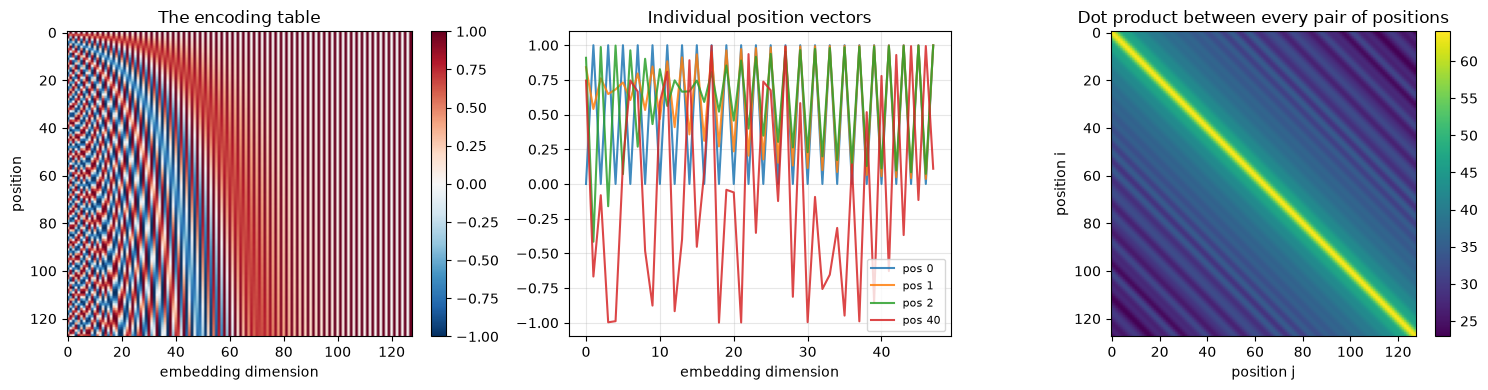

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im = axes[0].imshow(PE.numpy(), aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("The encoding table")
axes[0].set_xlabel("embedding dimension"); axes[0].set_ylabel("position")
fig.colorbar(im, ax=axes[0], fraction=0.046)

for p in (0, 1, 2, 40):
    axes[1].plot(PE[p, :48].numpy(), label=f"pos {p}", alpha=0.85)
axes[1].set_title("Individual position vectors")
axes[1].set_xlabel("embedding dimension"); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

sim = (PE @ PE.T).numpy()
im = axes[2].imshow(sim, cmap="viridis")
axes[2].set_title("Dot product between every pair of positions")
axes[2].set_xlabel("position j"); axes[2].set_ylabel("position i")
fig.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout(); plt.show()

The right panel is the important one. It is **banded along the diagonal**:
similarity depends mainly on $|i - j|$, the *distance* between positions, not on
where the pair sits in absolute terms. Let us confirm that is really true rather
than infer it from a picture.

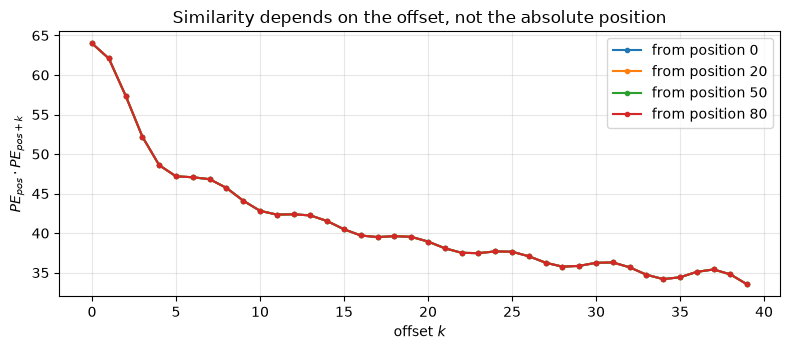

mean spread across starting positions, for a fixed offset: 0.0000
(near zero -> the four curves lie on top of each other, as the property predicts)


In [4]:
offsets = np.arange(0, 40)
rows = [0, 20, 50, 80]

plt.figure(figsize=(8, 3.6))
for r in rows:
    valid = [o for o in offsets if r + o < MAX_LEN]
    plt.plot(valid, [sim[r, r + o] for o in valid], marker=".", label=f"from position {r}")
plt.xlabel("offset $k$"); plt.ylabel(r"$PE_{pos} \cdot PE_{pos+k}$")
plt.title("Similarity depends on the offset, not the absolute position")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

spread = np.std([[sim[r, r + o] for r in rows] for o in range(1, 40)], axis=1).mean()
print(f"mean spread across starting positions, for a fixed offset: {spread:.4f}")
print("(near zero -> the four curves lie on top of each other, as the property predicts)")

📐 **A note on what modern models do.** Sinusoidal encodings are the original
recipe and still the clearest to reason about, but the field has largely moved
on:

- **Learned absolute embeddings** (BERT, ViT, and the DiT) simply make `PE` an
  `nn.Parameter` and train it. Simpler, works about as well, but cannot
  extrapolate past the trained length. Chapter 11 uses one, and you will watch it
  organize itself into a 2-D grid.
- **RoPE** (rotary position embedding, used by Llama, Qwen, and most current
  LLMs) rotates $Q$ and $K$ by a position-dependent angle instead of adding
  anything to the input, which bakes the relative-offset property directly into
  the attention scores rather than hoping the model learns to exploit it.

All three are answers to the same question: attention has no order, so where do
we inject it?


---
# Module 2 — Multi-Head Attention

## 2.1 The panel of reviewers

🧠 **The intuition.** One softmax row is one probability distribution: one
answer to "where should I look?". But a token often needs several unrelated
things at once: the verb it belongs to, the noun a pronoun refers to, the topic
of the paragraph. Forcing one distribution to serve all of those means averaging
them, and the average of three sharp answers is one blurry one.

Multi-head attention runs $h$ attention operations in parallel over *slices* of
the feature dimension, then concatenates the results. Think of a panel of
reviewers reading the same document: one checks grammar, one tone, one factual
consistency, and their notes are combined at the end rather than blended into a
single score.

**The part that makes it cheap.** Each head operates on $d_k =
d_{\text{model}}/h$ dimensions rather than the full width. Eight heads of width
64 hold the same parameters and do the same number of multiply-accumulates as
one head of width 512. Multi-head attention is a **rearrangement** of the same
budget rather than a bigger model. We will put that on a stopwatch in 2.3,
and find one place where the claim needs a caveat.

📐 **The math.** Project, split, attend independently, concatenate, project once
more:

$$ \text{head}_i = \text{Attention}(Q W_i^Q,\; K W_i^K,\; V W_i^V) \in \mathbb{R}^{n \times d_k} $$

$$ \boxed{\;\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\, W^O\;} $$

with $W_i^Q, W_i^K, W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_k}$ and
$W^O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$.

That output projection $W^O$ matters more than it looks. Without it the heads
would write into fixed, disjoint slots of the output vector; $W^O$ lets the
model mix what the heads found back into a shared representation.

💻 **In practice nobody loops over heads.** You use *one* $W_Q$ of full width
$d_{\text{model}} \times d_{\text{model}}$ and then **reshape** the result into
$h$ slices. Mathematically identical to $h$ separate matrices, but it is one big
matmul instead of $h$ small ones, which is a much better use of a GPU. The
reshape choreography is the only genuinely fiddly part of implementing a
Transformer, so let us walk the shapes one line at a time.


In [5]:
B, N, D, H = 2, 6, 64, 8            # batch, seq len, d_model, heads
d_k = D // H

x = torch.randn(B, N, D)
W_Q_demo = nn.Linear(D, D, bias=False)

step1 = W_Q_demo(x)                            # project at FULL width, all heads at once
step2 = step1.view(B, N, H, d_k)               # carve the last axis into H slices
step3 = step2.transpose(1, 2)                  # bring heads next to batch

def shp(t):
    return str(tuple(t.shape))


print(f"x                        {shp(x):>18}   (batch, seq, d_model)")
print(f"after W_Q                {shp(step1):>18}   one matmul, not {H}")
print(f".view(B, N, H, d_k)      {shp(step2):>18}   d_model = {H} heads x {d_k}")
print(f".transpose(1, 2)         {shp(step3):>18}   <- attention now batches over (B, H)")
print()
print("The transpose is what makes it work: scaled_dot_product_attention treats")
print("every leading axis as batch, so it runs all", B * H, "head-instances in one call.")

out, A = scaled_dot_product_attention(step3, step3, step3)
print(f"\nattention output         {shp(out):>18}")
print(f"attention weights        {shp(A):>18}   <- one n x n map PER HEAD")

merged = out.transpose(1, 2).reshape(B, N, D)   # undo the split == Concat(head_1..head_h)
print(f"\ntranspose back + reshape {shp(merged):>18}   <- this IS the Concat in the formula")

x                                (2, 6, 64)   (batch, seq, d_model)
after W_Q                        (2, 6, 64)   one matmul, not 8
.view(B, N, H, d_k)            (2, 6, 8, 8)   d_model = 8 heads x 8
.transpose(1, 2)               (2, 8, 6, 8)   <- attention now batches over (B, H)

The transpose is what makes it work: scaled_dot_product_attention treats
every leading axis as batch, so it runs all 16 head-instances in one call.

attention output               (2, 8, 6, 8)
attention weights              (2, 8, 6, 6)   <- one n x n map PER HEAD

transpose back + reshape         (2, 6, 64)   <- this IS the Concat in the formula


That final `transpose(1, 2).reshape(...)` **is** the $\text{Concat}$ in the
boxed equation. Concatenating $h$ tensors of width $d_k$ along the feature axis
is exactly the same memory layout as un-splitting them, so the "concatenate"
step costs nothing at all.

💻 **The module**, now that the shapes are clear.


In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, bias=False):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly among the heads"
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=bias)
        self.W_K = nn.Linear(d_model, d_model, bias=bias)
        self.W_V = nn.Linear(d_model, d_model, bias=bias)
        self.W_O = nn.Linear(d_model, d_model, bias=bias)

    def _split(self, t):
        B, N, _ = t.shape
        return t.view(B, N, self.n_heads, self.d_k).transpose(1, 2)     # (B, H, N, d_k)

    def forward(self, x, pad_mask=None, causal=False):
        B, N, D = x.shape
        Q, K, V = self._split(self.W_Q(x)), self._split(self.W_K(x)), self._split(self.W_V(x))

        mask = None
        if pad_mask is not None:
            mask = pad_mask[:, None, None, :]                            # broadcast over heads+queries
        if causal:
            tri = torch.tril(torch.ones(N, N, device=x.device))
            mask = tri if mask is None else mask * tri

        heads, A = scaled_dot_product_attention(Q, K, V, mask)           # (B, H, N, d_k)
        merged = heads.transpose(1, 2).reshape(B, N, D)                  # Concat
        return self.W_O(merged), A


mha = MultiHeadSelfAttention(D, H)
y, A = mha(x)
print("input :", tuple(x.shape), "-> output:", tuple(y.shape), "| attention:", tuple(A.shape))
print(f"parameters: {sum(p.numel() for p in mha.parameters()):,} = 4 x {D}x{D}")

input : (2, 6, 64) -> output: (2, 6, 64) | attention: (2, 8, 6, 6)
parameters: 16,384 = 4 x 64x64


## 2.2 Check it against PyTorch's implementation

The same discipline as Chapter 9: if our module is right, copying its weights
into `nn.MultiheadAttention` must reproduce our output exactly. This is also a
useful thing to know how to do, because torch packs $W_Q$, $W_K$, $W_V$ into a
**single** stacked `in_proj_weight` of shape $(3d, d)$, which is a detail you
will hit any time you load or convert pretrained checkpoints.


In [7]:
reference = nn.MultiheadAttention(D, H, bias=False, batch_first=True)

with torch.no_grad():
    reference.in_proj_weight.copy_(
        torch.cat([mha.W_Q.weight, mha.W_K.weight, mha.W_V.weight], dim=0)   # (3d, d)
    )
    reference.out_proj.weight.copy_(mha.W_O.weight)

ours, _ = mha(x)
theirs, _ = reference(x, x, x, need_weights=False)

max_diff = (ours - theirs).abs().max().item()
print(f"in_proj_weight shape: {tuple(reference.in_proj_weight.shape)}  <- W_Q, W_K, W_V stacked")
print(f"max absolute difference: {max_diff:.2e}")
assert max_diff < 1e-5
print("✓ our from-scratch multi-head attention is torch's, exactly")

in_proj_weight shape: (192, 64)  <- W_Q, W_K, W_V stacked
max absolute difference: 1.19e-07
✓ our from-scratch multi-head attention is torch's, exactly


## 2.3 How free is multi-head, exactly?

📐 **Work out the two budgets before measuring**, because they do not agree.

**Parameters** are trivially independent of $h$: the four projections are
$d_{\text{model}} \times d_{\text{model}}$ regardless of how the middle is
sliced. $4d^2$, always.

**FLOPs** also come out equal, but only after a cancellation worth seeing. One
head computes $QK^\top$ at a cost of $n^2 d_k$; there are $h$ heads; so the
total is $h \cdot n^2 d_k = h \cdot n^2 (d/h) = n^2 d$. The $h$ cancels.

**Memory does not cancel.** Each head materializes its own $n \times n$ score
matrix, so the attention tensor has shape $(B, h, n, n)$, which is **linear in
$h$**, with no $d_k$ to shrink in compensation. Eight heads means eight times
the score memory, and the softmax over it is eight times the elementwise work.

So the honest prediction is: parameters flat, FLOPs flat, memory linear in $h$,
and wall-clock flat *until* the score tensor grows large enough that attention
becomes memory-bandwidth-bound rather than compute-bound.

💻 **The code.** Measure all three.


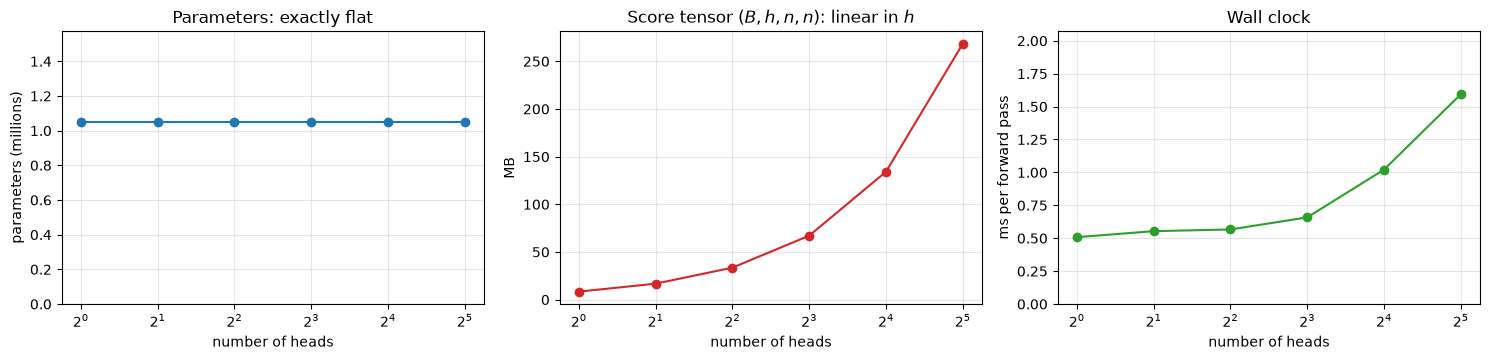

parameters : 1,048,576 at h=1 ... 1,048,576 at h=32   (identical)
score mem  : 8.4 MB at h=1 ... 268.4 MB at h=32   (32x)
time       : 0.508 ms at h=1 ... 1.594 ms at h=32   (3.14x)
time h=1 -> h=8 (the practical range): 0.508 -> 0.658 ms (1.30x)


In [8]:
D_BENCH, N_BENCH, B_BENCH = 512, 256, 32
head_counts = [1, 2, 4, 8, 16, 32]
params, timings, score_mb = [], [], []

xb = torch.randn(B_BENCH, N_BENCH, D_BENCH, device=device)

for h in head_counts:
    m = MultiHeadSelfAttention(D_BENCH, h).to(device)
    params.append(sum(p.numel() for p in m.parameters()))
    score_mb.append(B_BENCH * h * N_BENCH * N_BENCH * 4 / 1e6)      # (B, h, n, n) float32

    for _ in range(10):                                  # warm up
        m(xb)
    if device == "cuda":
        torch.cuda.synchronize()
        s, e = (torch.cuda.Event(enable_timing=True) for _ in range(2))
        s.record()
        for _ in range(50):
            m(xb)
        e.record(); torch.cuda.synchronize()
        timings.append(s.elapsed_time(e) / 50)
    else:
        import time
        t0 = time.time()
        for _ in range(5):
            m(xb)
        timings.append((time.time() - t0) / 5 * 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.7))
axes[0].plot(head_counts, [p / 1e6 for p in params], "o-")
axes[0].set_ylabel("parameters (millions)"); axes[0].set_title("Parameters: exactly flat")
axes[0].set_ylim(0, max(params) / 1e6 * 1.5)

axes[1].plot(head_counts, score_mb, "o-", color="tab:red")
axes[1].set_ylabel("MB"); axes[1].set_title(r"Score tensor $(B, h, n, n)$: linear in $h$")

axes[2].plot(head_counts, timings, "o-", color="tab:green")
axes[2].set_ylabel("ms per forward pass"); axes[2].set_title("Wall clock")
axes[2].set_ylim(0, max(timings) * 1.3)

for ax in axes:
    ax.set_xscale("log", base=2); ax.set_xlabel("number of heads"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"parameters : {params[0]:,} at h=1 ... {params[-1]:,} at h=32   (identical)")
print(f"score mem  : {score_mb[0]:.1f} MB at h=1 ... {score_mb[-1]:.1f} MB at h=32   "
      f"({score_mb[-1] / score_mb[0]:.0f}x)")
print(f"time       : {timings[0]:.3f} ms at h=1 ... {timings[-1]:.3f} ms at h=32   "
      f"({timings[-1] / timings[0]:.2f}x)")
print(f"time h=1 -> h=8 (the practical range): {timings[0]:.3f} -> {timings[3]:.3f} ms "
      f"({timings[3] / timings[0]:.2f}x)")

The prediction holds in all three panels. Parameters are a flat line at exactly
$4d^2$. Score memory is a straight line through the origin. Wall-clock rises by
about 30% from one head to eight, the range every real model actually uses, and
then climbs more steeply (roughly 3× by $h = 32$) as the score tensor passes a
hundred megabytes and the softmax starts waiting on memory bandwidth rather than
arithmetic.

So "multi-head is free" needs qualifying: free in parameters, free in FLOPs,
*not* free in activation memory, and cheap rather than free in wall-clock at the
head counts anyone uses. The memory term is also the reason FlashAttention
matters so much, since it avoids materializing this tensor at all, which is
precisely the term that scales with $h$.

Whether all these heads buy anything measurable on our task is Module 4's job,
and the answer is not the one you would expect.


---
# Module 3 — The Rest of the Block

## 3.1 The feed-forward network: where the nonlinearity (and most of the weight) lives

🧠 **The intuition.** Look hard at what attention computes: a weighted average
of value vectors, followed by a linear projection. **There is no elementwise
nonlinearity anywhere in it.** Stack two attention layers and, for fixed
attention weights, you still have a linear map. The softmax makes the *weights*
depend on the data, which does a great deal of work, but the value pathway is
linear throughout.

So every block follows attention with an ordinary MLP applied **independently and
identically to each position**, with no mixing across the sequence, since that
was attention's job. This is the division of labour that defines a Transformer:

- **Attention mixes information across positions.** No nonlinearity.
- **The FFN transforms each position on its own.** All the nonlinearity.

📐 **The math.** Expand to $4\times$ width, apply a nonlinearity, project back:

$$ \text{FFN}(x) = W_2 \,\sigma(W_1 x + b_1) + b_2, \qquad W_1 \in \mathbb{R}^{d \times 4d},\; W_2 \in \mathbb{R}^{4d \times d} $$

The original paper used ReLU; essentially everything modern uses **GELU** (a
smooth ReLU) or a gated variant like SwiGLU.

**Count the parameters**, because the result surprises most people:

$$ \underbrace{4d^2}_{\text{attention } (W_Q, W_K, W_V, W^O)} \quad\text{vs}\quad \underbrace{8d^2}_{\text{FFN } (d \to 4d \to d)} $$

**Two thirds of a Transformer's parameters are in the MLPs, not the attention.**
The mechanism the architecture is named after is the minority shareholder.

## 3.2 LayerNorm, and why not BatchNorm

🧠 **The intuition.** Your CNNs used BatchNorm, which normalizes each channel
using statistics computed *across the batch*. For sequences that is a bad fit for
two reasons. First, sequences have different lengths, so different positions are
backed by different numbers of real samples and the statistics get noisy exactly
where data is sparse. Second, it makes each example's output depend on the other
examples in its batch, awkward at training time, and at generation time you are
often running batch size 1.

**LayerNorm** normalizes across the **feature** dimension of each token
separately. No cross-example dependency, no cross-position dependency, identical
behaviour at train and inference, and completely indifferent to sequence length.

📐 **The math**, for one token's vector $x \in \mathbb{R}^d$:

$$ \text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta, \qquad \mu = \frac{1}{d}\sum_i x_i, \;\; \sigma^2 = \frac{1}{d}\sum_i (x_i - \mu)^2 $$

$\gamma$ and $\beta$ are learned per-feature scale and shift. **Remember this
equation.** Making $\gamma$ and $\beta$ *predicted from a conditioning vector*
instead of learned as free parameters turns out to be the whole conditioning
mechanism of a Diffusion Transformer, and Chapter 12 builds exactly that.


In [9]:
demo = torch.randn(4, 10, 32) * 3 + 5          # (batch, seq, features), badly scaled

ln = nn.LayerNorm(32)
normed = ln(demo)

print("LayerNorm normalizes along the FEATURE axis, per token:")
print(f"  before: per-token mean {demo.mean(-1)[0, :3].numpy().round(3)}, "
      f"std {demo.std(-1)[0, :3].numpy().round(3)}")
print(f"  after : per-token mean {normed.mean(-1)[0, :3].detach().numpy().round(3)}, "
      f"std {normed.std(-1)[0, :3].detach().numpy().round(3)}")
print(f"\nparameters: {sum(p.numel() for p in ln.parameters())} = gamma(32) + beta(32)")
print("\nNote what it does NOT touch: the batch axis and the sequence axis.")
print("That independence is why it works with variable-length inputs and batch size 1.")

LayerNorm normalizes along the FEATURE axis, per token:
  before: per-token mean [4.787 4.81  4.871], std [3.365 3.651 3.346]
  after : per-token mean [ 0.  0. -0.], std [1.016 1.016 1.016]

parameters: 64 = gamma(32) + beta(32)

Note what it does NOT touch: the batch axis and the sequence axis.
That independence is why it works with variable-length inputs and batch size 1.


## 3.3 Residuals, and *where* the norm goes

🧠 **The intuition.** Residual connections are the idea you already built in
Chapter 3: give the gradient an identity path so depth stops being an obstacle.
Every Transformer sub-layer is wrapped in one.

The subtle part is **where LayerNorm sits relative to the skip**, and the field
changed its mind about this:

$$ \textbf{Post-LN (original, 2017)}: \quad x \leftarrow \text{LayerNorm}\big(x + \text{SubLayer}(x)\big) $$

$$ \textbf{Pre-LN (everything modern)}: \quad x \leftarrow x + \text{SubLayer}\big(\text{LayerNorm}(x)\big) $$

The difference looks cosmetic and is not. In Post-LN the residual stream passes
*through* a LayerNorm at every block, so the identity path is not actually
clean, since the gradient is rescaled at every layer on the way back. In Pre-LN
the skip connection is a genuinely unbroken highway from the loss to the first
layer, and the normalization only guards the sub-layer's input.

The practical consequence: **Post-LN Transformers need a learning-rate warmup
schedule or they diverge**; Pre-LN ones largely do not (Xiong et al., 2020).

💻 **The code.** Measure it. Build twelve blocks each way, backpropagate once
from an untrained initialization, and look at the gradient that actually reaches
each layer's $W_Q$.


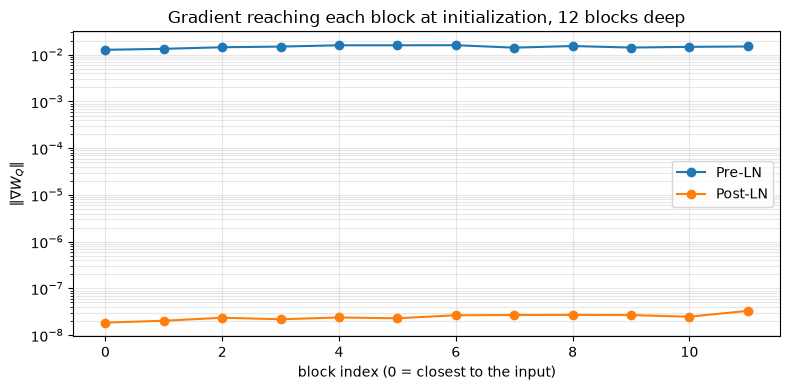

Pre-LN  gradient at block 0: 1.28e-02
Post-LN gradient at block 0: 1.85e-08

-> Post-LN delivers 7e+05x less gradient signal at the same depth.
   It is trainable with warmup, which is exactly why the original paper used one.
   Pre-LN removes the need, which is why every model since ~2020 uses it.


In [10]:
class ProbeBlock(nn.Module):
    def __init__(self, d, h, pre_ln):
        super().__init__()
        self.pre_ln = pre_ln
        self.attn = MultiHeadSelfAttention(d, h)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x):
        if self.pre_ln:
            x = x + self.attn(self.norm1(x))[0]
            x = x + self.ffn(self.norm2(x))
        else:
            x = self.norm1(x + self.attn(x)[0])
            x = self.norm2(x + self.ffn(x))
        return x


DEPTH = 12
grad_profiles = {}

for pre_ln in (True, False):
    torch.manual_seed(0)
    stack = nn.ModuleList([ProbeBlock(64, 8, pre_ln) for _ in range(DEPTH)])
    h = torch.randn(8, 32, 64)
    for blk in stack:
        h = blk(h)
    h.pow(2).mean().backward()
    key = "Pre-LN" if pre_ln else "Post-LN"
    grad_profiles[key] = [b.attn.W_Q.weight.grad.norm().item() for b in stack]

plt.figure(figsize=(8, 4))
for name, g in grad_profiles.items():
    plt.semilogy(range(DEPTH), g, marker="o", label=name)
plt.xlabel("block index (0 = closest to the input)")
plt.ylabel(r"$\|\nabla W_Q\|$")
plt.title("Gradient reaching each block at initialization, 12 blocks deep")
plt.legend(); plt.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()

pre, post = grad_profiles["Pre-LN"], grad_profiles["Post-LN"]
print(f"Pre-LN  gradient at block 0: {pre[0]:.2e}")
print(f"Post-LN gradient at block 0: {post[0]:.2e}")
print(f"\n-> Post-LN delivers {pre[0] / post[0]:.0e}x less gradient signal at the same depth.")
print("   It is trainable with warmup, which is exactly why the original paper used one.")
print("   Pre-LN removes the need, which is why every model since ~2020 uses it.")

## 3.4 Assembling the block

💻 Everything above, in one module. This is the complete unit: repeat it $L$
times and you have an encoder.


In [11]:
class TransformerEncoderBlock(nn.Module):
    '''Pre-LN encoder block: MHSA + FFN, each wrapped in a residual connection.'''

    def __init__(self, d_model, n_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, mlp_ratio * d_model),
            nn.GELU(),
            nn.Linear(mlp_ratio * d_model, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None, causal=False):
        attn_out, A = self.attn(self.norm1(x), pad_mask, causal)
        x = x + self.dropout(attn_out)          # residual 1: mixes ACROSS positions
        x = x + self.ffn(self.norm2(x))         # residual 2: transforms EACH position
        return x, A


block = TransformerEncoderBlock(D_MODEL, n_heads=8)
out, A = block(torch.randn(2, 16, D_MODEL))
print("block:", (2, 16, D_MODEL), "->", tuple(out.shape), "| attention:", tuple(A.shape))

attn_p = sum(p.numel() for p in block.attn.parameters())
ffn_p = sum(p.numel() for p in block.ffn.parameters())
norm_p = sum(p.numel() for n, p in block.named_parameters() if "norm" in n)
total = attn_p + ffn_p + norm_p

print(f"\nparameter budget at d_model = {D_MODEL}:")
print(f"  attention (4d²)  {attn_p:>9,}   {attn_p / total:5.1%}")
print(f"  FFN       (8d²)  {ffn_p:>9,}   {ffn_p / total:5.1%}")
print(f"  layernorms       {norm_p:>9,}   {norm_p / total:5.1%}")
print(f"  total            {total:>9,}")
print("\nThe FFN holds twice what attention does, as predicted in 3.1.")

block: (2, 16, 128) -> (2, 16, 128) | attention: (2, 8, 16, 16)

parameter budget at d_model = 128:
  attention (4d²)     65,536   33.1%
  FFN       (8d²)    131,712   66.6%
  layernorms             512    0.3%
  total              197,760

The FFN holds twice what attention does, as predicted in 3.1.


---
# Module 4 — Training It, and an Honest Result

💻 Stack the blocks into a classifier and run the same IMDB task as Chapter 9,
so the numbers are directly comparable. Chapter 9's single-head, single-layer,
no-position model reached **~79%**.

In [12]:
MAX_LEN = 128
N_TRAIN, N_TEST = 20_000, 5_000


def encode(split, n):
    ds = split.shuffle(seed=42).select(range(n))
    enc = tokenizer(list(ds["text"]), truncation=True, max_length=MAX_LEN,
                    padding="max_length", return_tensors="pt")
    return enc["input_ids"], enc["attention_mask"], torch.tensor(list(ds["label"]))


train_ids, train_mask, train_y = encode(imdb["train"], N_TRAIN)
test_ids, test_mask, test_y = encode(imdb["test"], N_TEST)
print("train:", tuple(train_ids.shape), "| test:", tuple(test_ids.shape))

train: (20000, 128) | test: (5000, 128)


In [13]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2,
                 max_len=MAX_LEN, n_classes=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pos", sinusoidal_encoding(max_len, d_model))
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, dropout=dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)                 # final norm, standard with Pre-LN
        self.head = nn.Linear(d_model, n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, ids, pad_mask):
        # scale embeddings by sqrt(d) so they are comparable in magnitude to the
        # unit-scale positional encodings we are about to add (Vaswani et al., 3.4)
        # slice the table to this batch's length, so shorter probe sentences work too
        x = self.embed(ids) * math.sqrt(self.d_model) + self.pos[:ids.shape[1]]
        x = self.dropout(x)

        maps = []
        for blk in self.blocks:
            x, A = blk(x, pad_mask)
            maps.append(A)

        x = self.norm(x)
        m = pad_mask.unsqueeze(-1).float()
        pooled = (x * m).sum(1) / m.sum(1).clamp(min=1)
        return self.head(pooled), maps


def train_model(n_heads=4, n_layers=2, epochs=6, lr=1e-3, seed=42, verbose=True):
    torch.manual_seed(seed)
    model = TransformerClassifier(tokenizer.vocab_size, n_heads=n_heads,
                                  n_layers=n_layers).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_ids, train_mask, train_y),
        batch_size=128, shuffle=True)

    accs = []
    for ep in range(epochs):
        model.train()
        for ids, msk, y in loader:
            ids, msk, y = ids.to(device), msk.to(device), y.to(device)
            loss = F.cross_entropy(model(ids, msk)[0], y)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for i in range(0, len(test_ids), 512):
                logits, _ = model(test_ids[i:i + 512].to(device),
                                  test_mask[i:i + 512].to(device))
                correct += (logits.argmax(-1).cpu() == test_y[i:i + 512]).sum().item()
        accs.append(correct / len(test_ids))
        if verbose:
            print(f"  epoch {ep + 1}/{epochs}  test acc {accs[-1]:.4f}")
    return model, accs


print(f"heads=4, layers=2, params: "
      f"{sum(p.numel() for p in TransformerClassifier(tokenizer.vocab_size).parameters()):,}")
model, accs = train_model()
print(f"\nbest: {max(accs):.4f}   (Chapter 9's single-head, no-positions model: ~0.79)")

heads=4, layers=2, params: 4,302,850


  epoch 1/6  test acc 0.7440


  epoch 2/6  test acc 0.7928


  epoch 3/6  test acc 0.8048


  epoch 4/6  test acc 0.8012


  epoch 5/6  test acc 0.8052


  epoch 6/6  test acc 0.7942

best: 0.8052   (Chapter 9's single-head, no-positions model: ~0.79)


## 4.1 Does head count matter? Measure it.

💻 Same model, same seed, same everything, and only $h$ changes. Recall from 2.3
that all four of these have **identical parameter counts**, so this is a clean
comparison of nothing but how the feature dimension is sliced.

**And a control.** Any difference between head counts is only meaningful next to
how much the *same* configuration varies from run to run, so we also train
$h = 4$ three times with different seeds. Without that baseline a small gap is
uninterpretable, which is how a lot of architecture folklore gets started.


In [14]:
head_results = {}
for h in (1, 2, 4, 8):
    _, a = train_model(n_heads=h, verbose=False)
    head_results[h] = a
    print(f"heads={h}: best test acc {max(a):.4f}")

print("\ncontrol: h=4, three different seeds:")
seed_best = []
for s in (0, 1, 2):
    _, a = train_model(n_heads=4, seed=s, verbose=False)
    seed_best.append(max(a))
    print(f"  seed={s}: {max(a):.4f}")

heads=1: best test acc 0.8044


heads=2: best test acc 0.8042


heads=4: best test acc 0.8052


heads=8: best test acc 0.8068

control: h=4, three different seeds:


  seed=0: 0.8058


  seed=1: 0.8040


  seed=2: 0.8034


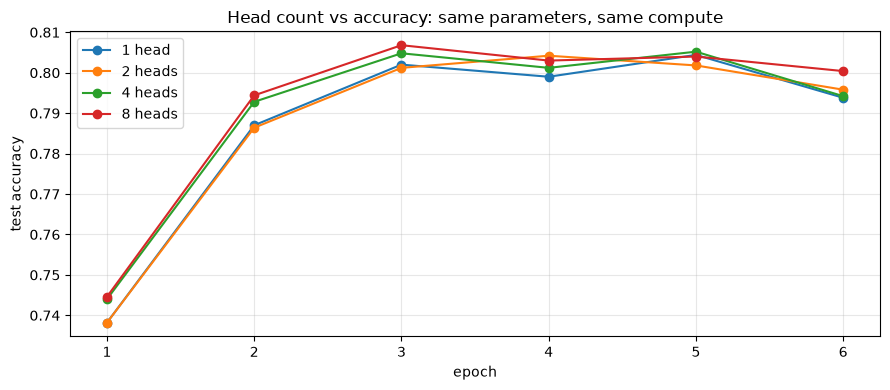

best accuracy by head count: {1: 0.8044, 2: 0.8042, 4: 0.8052, 8: 0.8068}

spread across head counts 1..8 : 0.0026
spread across seeds at h=4     : 0.0024   <- the noise floor

ratio: 1.08x the noise floor
-> indistinguishable from noise: no detectable head-count effect


In [15]:
plt.figure(figsize=(9, 4))
for h, a in head_results.items():
    plt.plot(range(1, len(a) + 1), a, marker="o", label=f"{h} head{'s' if h > 1 else ''}")
plt.xlabel("epoch"); plt.ylabel("test accuracy")
plt.title("Head count vs accuracy: same parameters, same compute")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best = {h: max(a) for h, a in head_results.items()}
head_spread = max(best.values()) - min(best.values())
seed_spread = max(seed_best) - min(seed_best)

print("best accuracy by head count:", {h: round(v, 4) for h, v in best.items()})
print(f"\nspread across head counts 1..8 : {head_spread:.4f}")
print(f"spread across seeds at h=4     : {seed_spread:.4f}   <- the noise floor")

ratio = head_spread / seed_spread
print(f"\nratio: {ratio:.2f}x the noise floor")
print("-> " + ("indistinguishable from noise: no detectable head-count effect"
                if ratio < 2 else
                "larger than noise: there is a real effect worth investigating"))

## 4.2 The honest reading

**Head count made essentially no difference.** The spread across 1, 2, 4 and 8
heads is the *same size* as what one configuration produces by changing nothing
but the random seed, and the two numbers agree to three decimal places, which
means the head-count ordering we observed carries no information at all. If you
were expecting the textbook "multi-head attention improves results", the
measurement declines to cooperate, and without the seed control we would have
had no way to know whether the ordering we saw meant anything.

This is worth sitting with rather than explaining away, and there are two things
going on.

**First, our task barely needs relational structure.** IMDB sentiment with
mean-pooling is close to a sophisticated bag-of-words problem: find the loaded
adjectives, count them. There is only really *one* relation worth modelling, so a
panel of four reviewers has nothing extra to contribute. Multi-head attention
pays off where several distinct relations genuinely coexist: syntactic
dependency, coreference, and topic in long documents, and in the vision and
diffusion settings of Chapters 11 and 12.

**Second, and this is the part the textbooks skip, the research literature
broadly agrees with our result.** Michel et al. (2019), in a paper titled *"Are
Sixteen Heads Really Better Than One?"*, found that a large fraction of heads in
trained BERT and machine-translation models can be **removed at test time with
almost no loss in performance**, sometimes leaving a single head per layer. Voita
et al. (2019) similarly found that only a small minority of heads take on
identifiable, specialized roles; the rest are largely redundant.

So what *is* multi-head attention buying? The current understanding is
**redundancy and easier optimization** rather than extra expressive power: many
parallel subspaces give the model more chances to stumble onto a useful pattern
during training, and it costs nothing (2.3) to provide them. Option value, not
capacity.

💻 **But do the heads at least learn *different* things?** That is a separate
question from whether they improve accuracy, and it has a different answer. If
heads were redundant copies their attention maps would be highly correlated;
let us measure the correlation.


In [16]:
model.eval()
with torch.no_grad():
    _, maps = model(test_ids[:64].to(device), test_mask[:64].to(device))

for layer_i, A in enumerate(maps):
    A_mean = A.float().mean(0)                              # (H, N, N), averaged over batch
    h = A_mean.shape[0]
    corr = np.corrcoef(A_mean.reshape(h, -1).cpu().numpy())
    off_diag = corr[~np.eye(h, dtype=bool)]
    print(f"layer {layer_i}: mean pairwise correlation between head attention maps "
          f"= {off_diag.mean():.3f}  (range {off_diag.min():.3f} to {off_diag.max():.3f})")

print("\n0 = the heads attend to completely unrelated things.")
print("1 = they are redundant copies of each other.")

layer 0: mean pairwise correlation between head attention maps = 0.072  (range 0.046 to 0.119)
layer 1: mean pairwise correlation between head attention maps = 0.044  (range -0.001 to 0.112)

0 = the heads attend to completely unrelated things.
1 = they are redundant copies of each other.


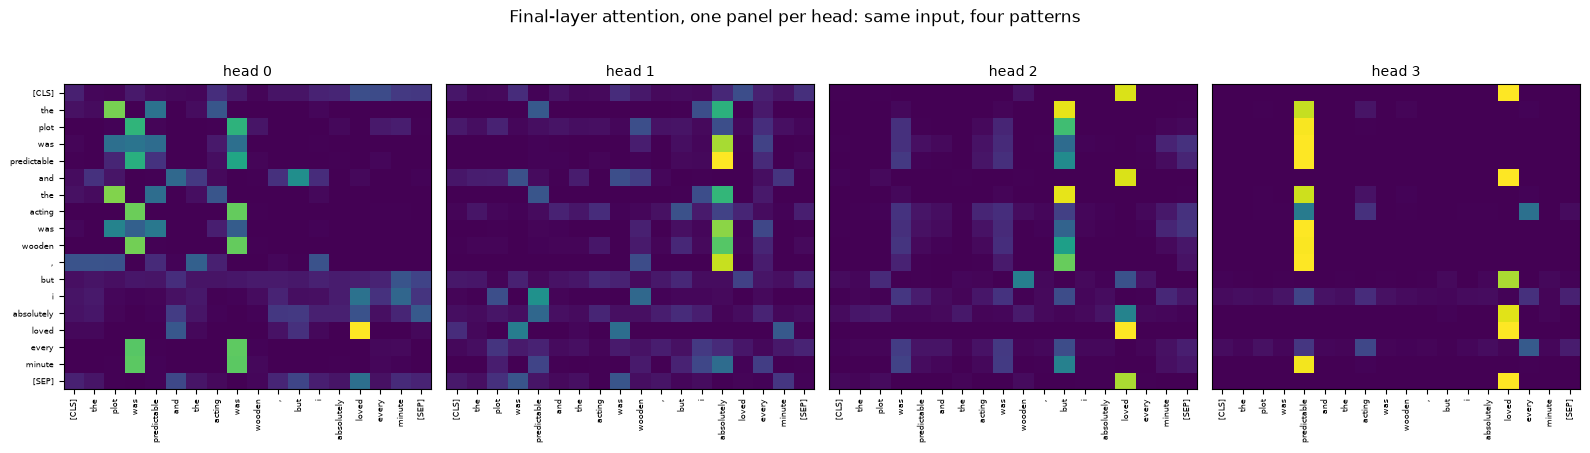

verdict on the probe sentence: negative
(Chapter 9's model also said negative. Two negative words still outvote one
 positive one. Positional encodings let the model *represent* order, but
 nothing in mean-pooled sentiment training forces it to *use* order this way.)


In [17]:
probe = "the plot was predictable and the acting was wooden , but i absolutely loved every minute"
enc = tokenizer(probe, return_tensors="pt")
p_ids, p_mask = enc["input_ids"].to(device), enc["attention_mask"].to(device)
p_tokens = tokenizer.convert_ids_to_tokens(p_ids[0])

with torch.no_grad():
    logits, maps = model(p_ids, p_mask)

A_last = maps[-1][0].float().cpu().numpy()                  # (H, n, n)
fig, axes = plt.subplots(1, len(A_last), figsize=(4 * len(A_last), 4.4))
for k, ax in enumerate(axes):
    ax.imshow(A_last[k], cmap="viridis", aspect="auto")
    ax.set_title(f"head {k}", fontsize=10)
    ax.set_xticks(range(len(p_tokens)))
    ax.set_xticklabels(p_tokens, rotation=90, fontsize=6)
    ax.set_yticks(range(len(p_tokens)) if k == 0 else [])
    if k == 0:
        ax.set_yticklabels(p_tokens, fontsize=6)
fig.suptitle("Final-layer attention, one panel per head: same input, four patterns", y=1.02)
plt.tight_layout(); plt.show()

print("verdict on the probe sentence:",
      "positive" if logits.argmax().item() == 1 else "negative")
print("(Chapter 9's model also said negative. Two negative words still outvote one")
print(" positive one. Positional encodings let the model *represent* order, but")
print(" nothing in mean-pooled sentiment training forces it to *use* order this way.)")

**Near-zero correlation.** The heads are not redundant copies; they genuinely
divide the input up in different ways, and the four panels look visibly
different. That is the mechanism working exactly as advertised.

And yet accuracy did not move. Both facts are true at once, and holding them
together is the accurate picture of multi-head attention: **the diversity is
real, the benefit on any particular task is not guaranteed.** Being able to say
that, rather than reciting the panel-of-reviewers story and stopping, is the
difference between having read about attention and having measured it.


---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| Sinusoidal positional encoding | Attention is order-blind by construction; order is *added to the input*. Identical maths to Chapter 8's timestep embedding |
| Multi-head attention | One big matmul + a reshape, not $h$ small ones. `view` → `transpose` → attend → `transpose` → `reshape`, and the last reshape *is* the concatenation |
| Weight-copy validation vs `nn.MultiheadAttention` | torch stacks $W_Q,W_K,W_V$ into one `in_proj_weight`, the detail you hit when converting checkpoints |
| The cost measurement | $h$ heads of width $d/h$ are parameter- and FLOP-identical to 1 head of width $d$, but the score tensor is $(B,h,n,n)$, linear in $h$. Flat wall-clock to $h=8$, then memory-bound |
| Position-wise FFN | Attention mixes across positions with no nonlinearity; the FFN adds nonlinearity with no mixing. **Two thirds of the parameters live here** |
| LayerNorm | Normalizes across features, per token, so it is indifferent to sequence length and batch size |
| Pre-LN vs Post-LN | Where the norm sits relative to the skip decides whether you need warmup; measured a gap of nearly $10^6$ in gradient at depth 12 |
| The head-count sweep | A negative result, honestly reported, and the literature that agrees with it |

**The block you now have is architecture-complete.** Not "a simplified version
of" a Transformer encoder block, but the real thing, modulo scale and a few
efficiency tricks. Stack 12 with $d_{\text{model}} = 768$ and 12 heads and you
have BERT-base's architecture exactly.

**Which means the next two chapters change almost no code at all.** That is the
surprising part, and it is the payoff for having built this carefully:

- **Vision Transformers (Chapter 11)** keep this block *byte for byte* and change
  only what produces the tokens. Instead of a vocabulary lookup, cut the image
  into 4×4 patches and linearly project each one. That is the whole idea. Along
  the way we will meet the honest limitation of ViTs, since they throw away the
  translation-equivariance prior your CNNs got for free, and they make you pay
  for it in data.
- **Diffusion Transformers (Chapter 12)** keep the block again and change only
  how conditioning enters: the $\gamma$ and $\beta$ of 3.2's LayerNorm stop
  being free parameters and start being *predicted from the diffusion timestep*.
  Swap that in, feed it noisy image patches instead of words, and the U-Net from
  Chapter 8 is replaced by the architecture behind Stable Diffusion 3 and Sora.
